<a href="https://colab.research.google.com/github/Sibitenda/Diploma/blob/main/advanced_surface_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Advanced Teaching Notebook: Surface Modeling (Week 8-9)

This notebook provides a complete teaching flow for surface modeling, covering:

- Curve to Surface transition
- Analytical surfaces (Plane, Ruled, Revolution, Tabulated)
- Synthetic surfaces (intro: Bézier/B-spline concepts)
- Mesh modeling
- Shading concepts (visualization)
- Real-world dataset application (Kaggle-style terrain)

Each section includes explanations, code, and guided questions for classroom use.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata


## 1. From Curve to Surface

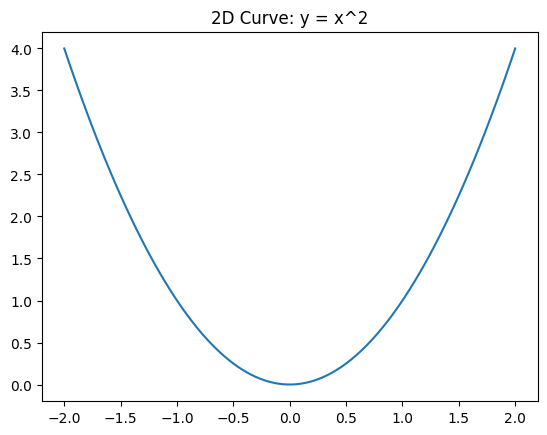

In [ ]:

x = np.linspace(-2,2,100)
y = x**2
plt.plot(x,y)
plt.title("2D Curve: y = x^2")
plt.show()



We extend curves into surfaces by introducing a second parameter.


## 2. Parametric Surface

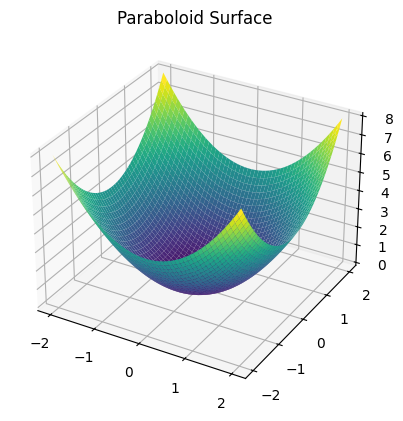

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define parameter ranges (u and v)
u_values = np.linspace(-2, 2, 50)   # controls horizontal direction
v_values = np.linspace(-2, 2, 50)   # controls vertical direction

# Step 2: Create a 2D grid from parameters
U_grid, V_grid = np.meshgrid(u_values, v_values)

# Step 3: Define the surface equation (Paraboloid)
Z_surface = U_grid**2 + V_grid**2

# Step 4: Initialize 3D plotting environment
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot the surface
axis.plot_surface(U_grid, V_grid, Z_surface, cmap='viridis')

# Step 6: Add title and display
axis.set_title("Paraboloid Surface")
plt.show()


Try modifying Z to explore different surfaces such as wave surfaces.


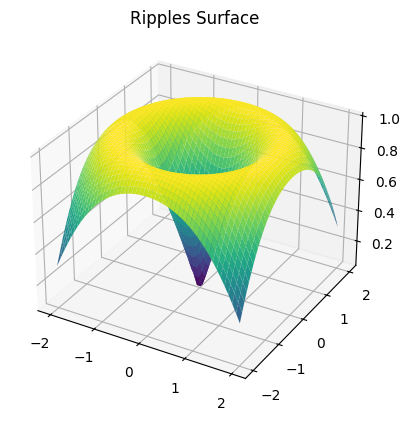

In [ ]:
Z_surface = np.sin(np.sqrt(U_grid**2 + V_grid**2))

# Step 4: Initialize 3D plotting environment
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot the surface
axis.plot_surface(U_grid, V_grid, Z_surface, cmap='viridis')

# Step 6: Add title and display
axis.set_title("Ripples Surface")
plt.show()

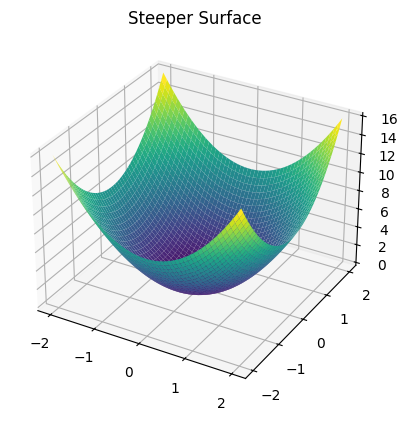

In [ ]:
Z_surface = (U_grid**2 + V_grid**2) * 2
# Step 4: Initialize 3D plotting environment
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot the surface
axis.plot_surface(U_grid, V_grid, Z_surface, cmap='viridis')

# Step 6: Add title and display
axis.set_title("Steeper Surface")
plt.show()


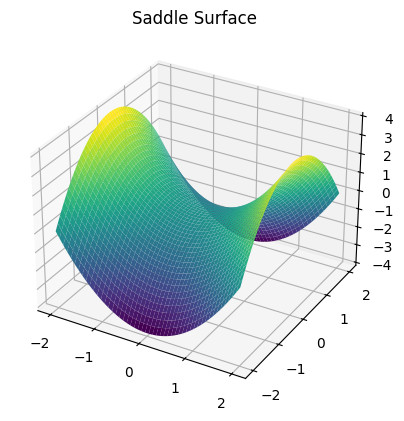

In [ ]:
Z_surface = U_grid**2 - V_grid**2
# Step 4: Initialize 3D plotting environment
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot the surface
axis.plot_surface(U_grid, V_grid, Z_surface, cmap='viridis')

# Step 6: Add title and display
axis.set_title("Saddle Surface")
plt.show()

## 3. Analytical Surfaces

### 3.1 Plane Surface

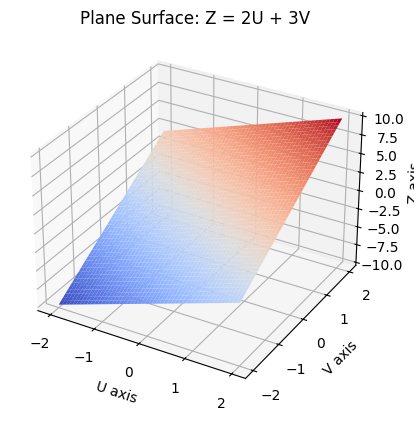

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Create parameter ranges
u_values = np.linspace(-2, 2, 50)   # horizontal direction
v_values = np.linspace(-2, 2, 50)   # vertical direction

# Step 2: Create grid
U_grid, V_grid = np.meshgrid(u_values, v_values)

# Step 3: Define plane equation
Z_surface = 2 * U_grid + 3 * V_grid

# Step 4: Initialize 3D plotting environment
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot the surface
axis.plot_surface(U_grid, V_grid, Z_surface, cmap='coolwarm', edgecolor='none')

# Step 6: Add labels and title
axis.set_title("Plane Surface: Z = 2U + 3V")
axis.set_xlabel("U axis")
axis.set_ylabel("V axis")
axis.set_zlabel("Z axis")

# Step 7: Display plot
plt.show()

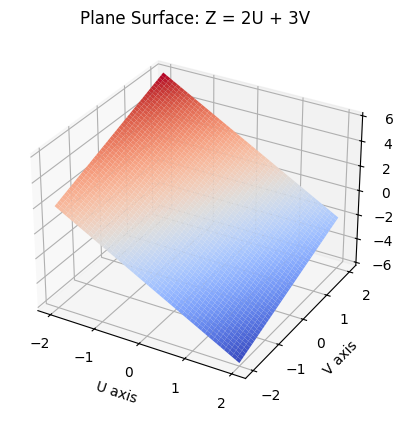

In [ ]:
Z_surface = -2 * U_grid + 1 * V_grid
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot the surface
axis.plot_surface(U_grid, V_grid, Z_surface, cmap='coolwarm', edgecolor='none')

# Step 6: Add labels and title
axis.set_title("Plane Surface: Z = 2U + 3V")
axis.set_xlabel("U axis")
axis.set_ylabel("V axis")
axis.set_zlabel("Z axis")

# Step 7: Display plot
plt.show()

### 3.2 Ruled Surface

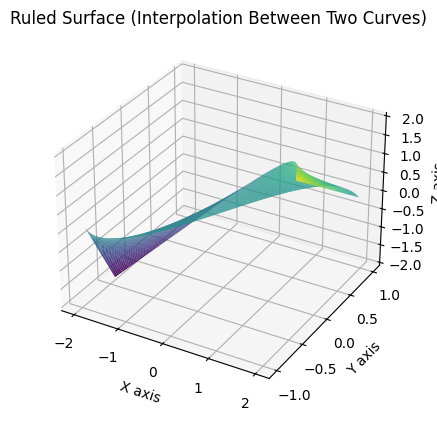

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define parameters
u_values = np.linspace(-2, 2, 50)   # controls position along the curves
t_values = np.linspace(0, 1, 50)    # controls interpolation between curves

# Step 2: Create parameter grid
T_grid, U_grid = np.meshgrid(t_values, u_values)

# Step 3: Define Curve 1 (base curve)
C1_x = U_grid
C1_y = np.sin(U_grid)
C1_z = np.zeros_like(U_grid)   # flat curve (z = 0)

# Step 4: Define Curve 2 (elevated curve)
C2_x = U_grid
C2_y = np.cos(U_grid)
C2_z = U_grid                  # rises upward

# Step 5: Interpolate between the two curves
X_surface = (1 - T_grid) * C1_x + T_grid * C2_x
Y_surface = (1 - T_grid) * C1_y + T_grid * C2_y
Z_surface = (1 - T_grid) * C1_z + T_grid * C2_z

# Step 6: Create 3D plot
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 7: Plot surface
axis.plot_surface(X_surface, Y_surface, Z_surface, cmap='viridis', edgecolor='none')

# Step 8: Add labels and title
axis.set_title("Ruled Surface (Interpolation Between Two Curves)")
axis.set_xlabel("X axis")
axis.set_ylabel("Y axis")
axis.set_zlabel("Z axis")

# Step 9: Display
plt.show()

### 3.3 Surface of Revolution

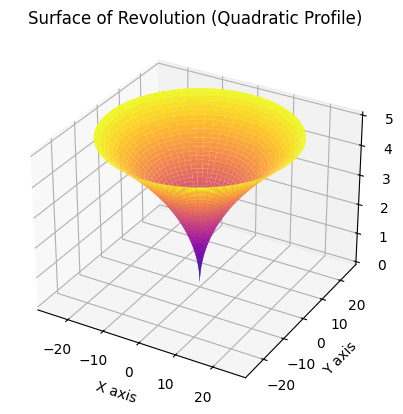

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define profile curve (radius as a function of height)
z_values = np.linspace(0, 5, 100)     # vertical axis (height)
radius = z_values**2                  # quadratic curve (profile)

# Step 2: Define rotation angle
theta_values = np.linspace(0, 2*np.pi, 100)   # full rotation (0 → 360 degrees)

# Step 3: Create parameter grid
Theta_grid, Z_grid = np.meshgrid(theta_values, z_values)

# Step 4: Expand radius to match grid shape
R_grid = Z_grid**2   # same equation as radius

# Step 5: Convert from cylindrical to Cartesian coordinates
X_surface = R_grid * np.cos(Theta_grid)
Y_surface = R_grid * np.sin(Theta_grid)
Z_surface = Z_grid

# Step 6: Create 3D plot
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 7: Plot surface
axis.plot_surface(X_surface, Y_surface, Z_surface, cmap='plasma', edgecolor='none')

# Step 8: Add labels and title
axis.set_title("Surface of Revolution (Quadratic Profile)")
axis.set_xlabel("X axis")
axis.set_ylabel("Y axis")
axis.set_zlabel("Z axis")

# Step 9: Display plot
plt.show()

### 3.4 Tabulated Surface (Extrusion)

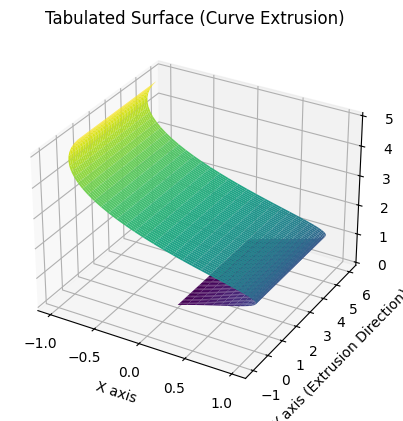

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define base curve (profile curve)
z_values = np.linspace(0, 5, 50)   # parameter along the curve

x_curve = np.sin(z_values)         # x-coordinates of curve
y_curve = np.cos(z_values)         # y-coordinates of curve

# Step 2: Define extrusion direction
t_values = np.linspace(0, 5, 50)   # how far we extend the surface

# Step 3: Create parameter grid
Z_grid, T_grid = np.meshgrid(z_values, t_values)

# Step 4: Expand curve along extrusion direction
X_surface = np.tile(x_curve, (len(t_values), 1))   # repeat curve in X
Y_surface = np.tile(y_curve, (len(t_values), 1)) + T_grid  # shift along Y
Z_surface = Z_grid                                # height remains same

# Step 5: Create 3D plot
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 6: Plot surface
axis.plot_surface(X_surface, Y_surface, Z_surface, cmap='viridis', edgecolor='none')

# Step 7: Add labels and title
axis.set_title("Tabulated Surface (Curve Extrusion)")
axis.set_xlabel("X axis")
axis.set_ylabel("Y axis (Extrusion Direction)")
axis.set_zlabel("Z axis")

# Step 8: Display
plt.show()

## 4. Mesh Modeling

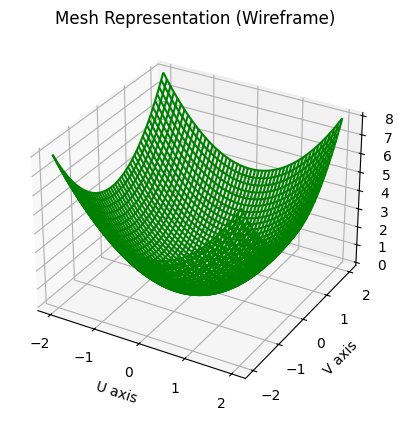

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define parameter ranges
u_values = np.linspace(-2, 2, 50)
v_values = np.linspace(-2, 2, 50)

# Step 2: Create grid (mesh points)
U_grid, V_grid = np.meshgrid(u_values, v_values)

# Step 3: Define surface (same as paraboloid)
Z_surface = U_grid**2 + V_grid**2

# Step 4: Initialize 3D plotting environment
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot wireframe (mesh structure only)
axis.plot_wireframe(U_grid, V_grid, Z_surface, color='green')

# Step 6: Add labels and title
axis.set_title("Mesh Representation (Wireframe)")
axis.set_xlabel("U axis")
axis.set_ylabel("V axis")
axis.set_zlabel("Z axis")

# Step 7: Display
plt.show()

## 5. Shading (Visualization)

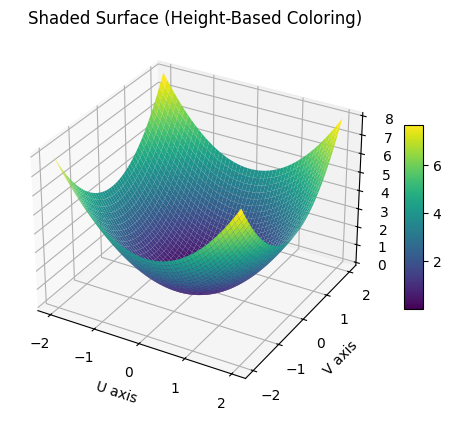

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define parameter ranges
u_values = np.linspace(-2, 2, 50)
v_values = np.linspace(-2, 2, 50)

# Step 2: Create grid (surface points)
U_grid, V_grid = np.meshgrid(u_values, v_values)

# Step 3: Define surface equation (paraboloid)
Z_surface = U_grid**2 + V_grid**2

# Step 4: Initialize 3D plotting environment
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot surface with shading (color mapping)
surface_plot = axis.plot_surface(
    U_grid, V_grid, Z_surface,
    cmap='viridis',        # color map for shading
    edgecolor='none'       # remove mesh lines for smooth look
)

# Step 6: Add color bar (shows height variation)
figure.colorbar(surface_plot, shrink=0.5, aspect=10)

# Step 7: Add labels and title
axis.set_title("Shaded Surface (Height-Based Coloring)")
axis.set_xlabel("U axis")
axis.set_ylabel("V axis")
axis.set_zlabel("Z axis")

# Step 8: Display plot
plt.show()

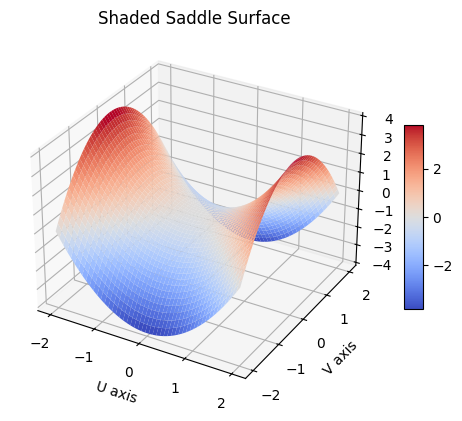

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define parameter ranges
u_values = np.linspace(-2, 2, 50)
v_values = np.linspace(-2, 2, 50)

# Step 2: Create grid
U_grid, V_grid = np.meshgrid(u_values, v_values)

# Step 3: Define saddle surface
Z_surface = U_grid**2 - V_grid**2

# Step 4: Create plot
figure = plt.figure()
axis = figure.add_subplot(111, projection='3d')

# Step 5: Plot shaded surface
surface_plot = axis.plot_surface(
    U_grid, V_grid, Z_surface,
    cmap='coolwarm',
    edgecolor='none'
)

# Step 6: Add color bar
figure.colorbar(surface_plot, shrink=0.5, aspect=10)

# Step 7: Labels and title
axis.set_title("Shaded Saddle Surface")
axis.set_xlabel("U axis")
axis.set_ylabel("V axis")
axis.set_zlabel("Z axis")

# Step 8: Show
plt.show()

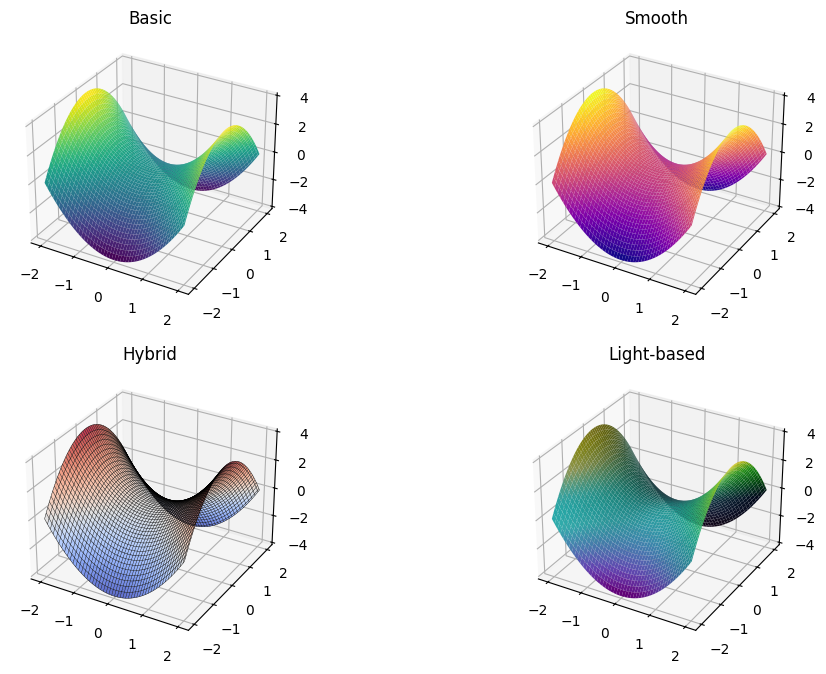

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import LightSource

# Create grid
u = np.linspace(-2, 2, 100)
v = np.linspace(-2, 2, 100)
U, V = np.meshgrid(u, v)

# Example surface (saddle)
Z = U**2 - V**2

fig = plt.figure(figsize=(12,8))

# 1 Basic
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot_surface(U, V, Z, cmap='viridis')
ax1.set_title("Basic")

# 2 Smooth
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_surface(U, V, Z, cmap='plasma', edgecolor='none')
ax2.set_title("Smooth")

# 3 Hybrid
ax3 = fig.add_subplot(223, projection='3d')
ax3.plot_surface(U, V, Z, cmap='coolwarm', alpha=0.8)
ax3.plot_wireframe(U, V, Z, color='black', linewidth=0.3)
ax3.set_title("Hybrid")

# 4 Light shading
ax4 = fig.add_subplot(224, projection='3d')
ls = LightSource(azdeg=45, altdeg=45)
rgb = ls.shade(Z, cmap=cm.viridis)
ax4.plot_surface(U, V, Z, facecolors=rgb, linewidth=0)
ax4.set_title("Light-based")

plt.show()


## 6. Synthetic Surfaces (Concept)

- Bézier surfaces: global control
- B-spline surfaces: local control
These are used in CAD and animation.


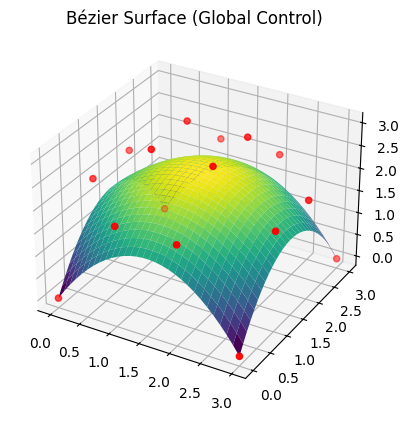

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define control points (4x4 grid)
control_points = np.array([
    [[0,0,0], [1,0,2], [2,0,2], [3,0,0]],
    [[0,1,2], [1,1,3], [2,1,3], [3,1,2]],
    [[0,2,2], [1,2,3], [2,2,3], [3,2,2]],
    [[0,3,0], [1,3,2], [2,3,2], [3,3,0]]
])

# Step 2: Bernstein polynomial
def bernstein(i, n, t):
    from math import comb
    return comb(n, i) * (t**i) * ((1-t)**(n-i))

# Step 3: Generate surface
u_vals = np.linspace(0,1,30)
v_vals = np.linspace(0,1,30)

X = np.zeros((30,30))
Y = np.zeros((30,30))
Z = np.zeros((30,30))

n = 3  # degree

for i, u in enumerate(u_vals):
    for j, v in enumerate(v_vals):
        for k in range(4):
            for l in range(4):
                b = bernstein(k,n,u) * bernstein(l,n,v)
                X[i,j] += b * control_points[k,l,0]
                Y[i,j] += b * control_points[k,l,1]
                Z[i,j] += b * control_points[k,l,2]

# Step 4: Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Plot control points
cp = control_points.reshape(-1,3)
ax.scatter(cp[:,0], cp[:,1], cp[:,2], color='red')

ax.set_title("Bézier Surface (Global Control)")
plt.show()

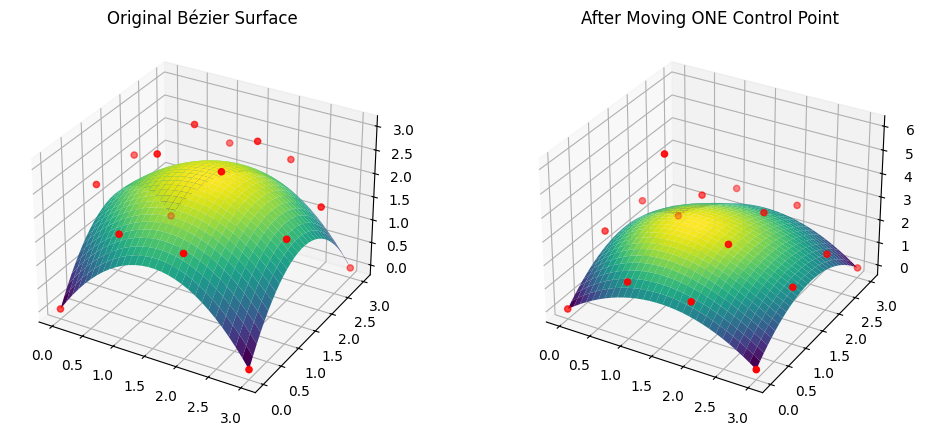

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Original control points
control_points_original = np.array([
    [[0,0,0], [1,0,2], [2,0,2], [3,0,0]],
    [[0,1,2], [1,1,3], [2,1,3], [3,1,2]],
    [[0,2,2], [1,2,3], [2,2,3], [3,2,2]],
    [[0,3,0], [1,3,2], [2,3,2], [3,3,0]]
])

# Step 2: Create modified version (change ONE control point)
control_points_modified = control_points_original.copy()
control_points_modified[1,1,2] += 3   # move one point upward

# Step 3: Bernstein polynomial
def bernstein(i, n, t):
    from math import comb
    return comb(n, i) * (t**i) * ((1-t)**(n-i))

# Step 4: Function to generate Bézier surface
def generate_surface(control_points):
    u_vals = np.linspace(0,1,30)
    v_vals = np.linspace(0,1,30)

    X = np.zeros((30,30))
    Y = np.zeros((30,30))
    Z = np.zeros((30,30))

    n = 3

    for i, u in enumerate(u_vals):
        for j, v in enumerate(v_vals):
            for k in range(4):
                for l in range(4):
                    b = bernstein(k,n,u) * bernstein(l,n,v)
                    X[i,j] += b * control_points[k,l,0]
                    Y[i,j] += b * control_points[k,l,1]
                    Z[i,j] += b * control_points[k,l,2]

    return X, Y, Z

# Step 5: Generate both surfaces
X1, Y1, Z1 = generate_surface(control_points_original)
X2, Y2, Z2 = generate_surface(control_points_modified)

# Step 6: Plot side-by-side
fig = plt.figure(figsize=(12,5))

# Original
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, Y1, Z1, cmap='viridis', edgecolor='none')
cp1 = control_points_original.reshape(-1,3)
ax1.scatter(cp1[:,0], cp1[:,1], cp1[:,2], color='red')
ax1.set_title("Original Bézier Surface")

# Modified
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X2, Y2, Z2, cmap='viridis', edgecolor='none')
cp2 = control_points_modified.reshape(-1,3)
ax2.scatter(cp2[:,0], cp2[:,1], cp2[:,2], color='red')
ax2.set_title("After Moving ONE Control Point")

plt.show()

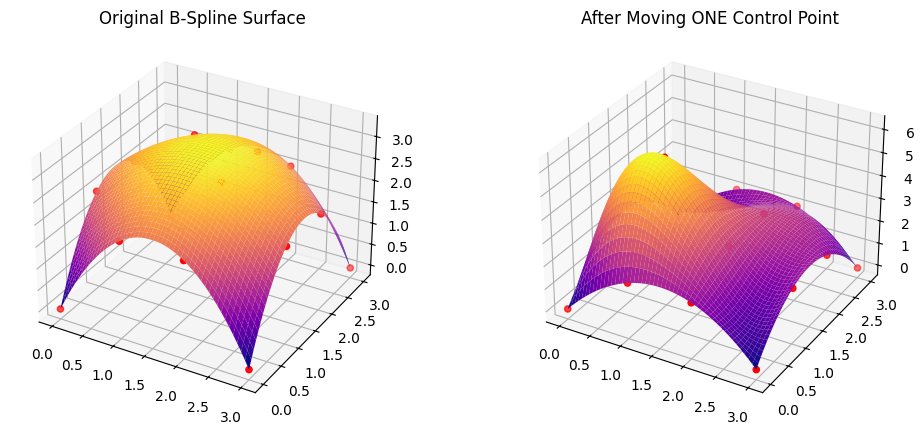

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

# Step 1: Define control grid
x = np.linspace(0,3,4)
y = np.linspace(0,3,4)

X, Y = np.meshgrid(x,y)

Z_original = np.array([
    [0,2,2,0],
    [2,3,3,2],
    [2,3,3,2],
    [0,2,2,0]
])

# Step 2: Modify ONE control point
Z_modified = Z_original.copy()
Z_modified[1,1] += 3   # change one point

# Step 3: Create spline surfaces
spline_original = RectBivariateSpline(x, y, Z_original)
spline_modified = RectBivariateSpline(x, y, Z_modified)

# Step 4: Evaluate surfaces
x_new = np.linspace(0,3,50)
y_new = np.linspace(0,3,50)

X_new, Y_new = np.meshgrid(x_new, y_new)

Z1 = spline_original(x_new, y_new)
Z2 = spline_modified(x_new, y_new)

# Step 5: Plot comparison
fig = plt.figure(figsize=(12,5))

# Original
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_new, Y_new, Z1, cmap='plasma', edgecolor='none')
ax1.scatter(X, Y, Z_original, color='red')
ax1.set_title("Original B-Spline Surface")

# Modified
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_new, Y_new, Z2, cmap='plasma', edgecolor='none')
ax2.scatter(X, Y, Z_modified, color='red')
ax2.set_title("After Moving ONE Control Point")

plt.show()

## 7. Real Dataset Application (Terrain Modeling)



> Add blockquote


We simulate a Kaggle-like terrain dataset (height grid).


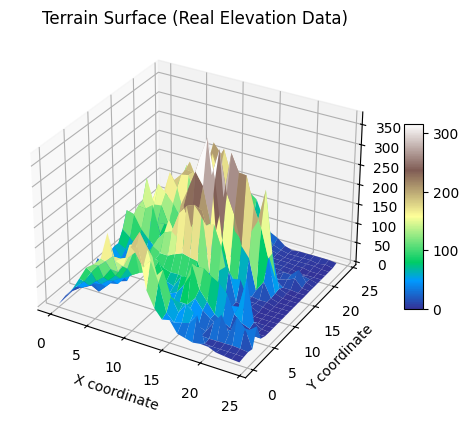

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Load dataset (public elevation grid)
url = "https://raw.githubusercontent.com/plotly/datasets/master/api_docs/mt_bruno_elevation.csv"

df = pd.read_csv(url)

# Step 2: Convert to numpy array (Z values = elevation)
Z = df.values

# Step 3: Create coordinate grid
x = np.arange(Z.shape[1])
y = np.arange(Z.shape[0])
X, Y = np.meshgrid(x, y)

# Step 4: Plot surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(X, Y, Z, cmap='terrain', edgecolor='none')

# Step 5: Add color bar (height reference)
fig.colorbar(surface, shrink=0.5, aspect=10)

# Step 6: Labels and title
ax.set_title("Terrain Surface (Real Elevation Data)")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.set_zlabel("Elevation")

plt.show()

In [ ]:
df.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,0,27.809850,49.61936,83.080670,116.66320,130.41400,150.72060,220.1871,156.1536,148.6416,...,49.96142,21.89279,17.02552,11.743170,14.752260,13.667100,5.677561,3.312340,1.156517,-0.147662
1,1,27.719660,48.55022,65.213740,95.27666,116.99640,133.90560,152.3412,151.9340,160.1139,...,33.08871,38.40972,44.24843,69.578600,4.019351,3.050024,3.039719,2.996142,2.967954,1.999594
2,2,30.426700,33.47752,44.809530,62.47495,77.43523,104.21530,102.7393,137.0004,186.0706,...,48.47132,74.71461,60.09090,7.073525,6.089851,6.537450,6.666096,7.306965,5.736840,3.625628
3,3,16.665490,30.10860,39.969520,44.12225,59.57512,77.56929,106.8925,166.5539,175.2381,...,60.55916,55.92124,15.17284,8.248324,36.680870,61.934130,20.268670,68.588190,46.498120,0.236010
4,4,8.815617,18.35160,8.658275,27.58590,48.62691,60.18013,91.3286,145.7109,116.0653,...,47.42691,69.20731,44.95468,29.171970,17.916740,16.255150,14.655590,17.260480,31.222450,46.717040


### Apply Smoothing

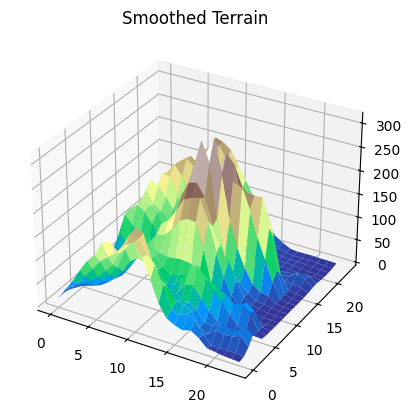

In [ ]:

Z_smooth = (Z[:-1,:-1]+Z[1:,:-1]+Z[:-1,1:]+Z[1:,1:])/4

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X[:-1,:-1],Y[:-1,:-1],Z_smooth, cmap='terrain')
plt.title("Smoothed Terrain")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2014_us_cities.csv"
df = pd.read_csv(url)

# Extract coordinates
x = df['lon'].values
y = df['lat'].values

# Simulate tweet density
np.random.seed(1)
z = np.random.rand(len(x)) * 200

# Create grid
grid_x, grid_y = np.mgrid[min(x):max(x):100j,
                          min(y):max(y):100j]

# Interpolate surface
grid_z = griddata((x,y), z, (grid_x,grid_y), method='cubic')

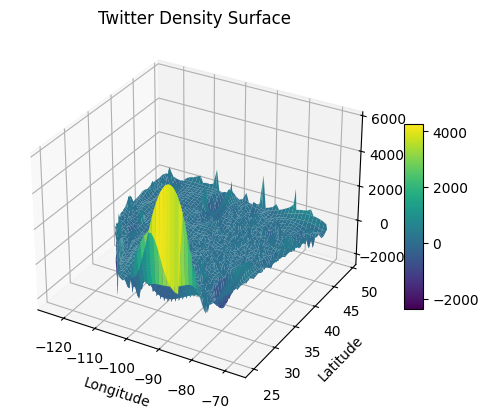

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis', edgecolor='none')

fig.colorbar(surf, shrink=0.5, aspect=10)

ax.set_title("Twitter Density Surface")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Density")

plt.show()

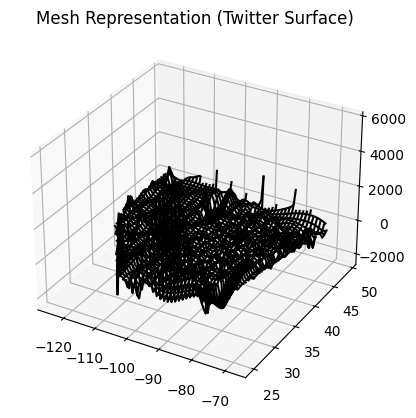

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(grid_x, grid_y, grid_z, color='black')

ax.set_title("Mesh Representation (Twitter Surface)")
plt.show()

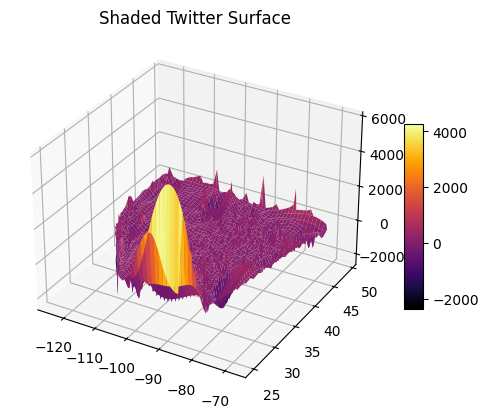

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(grid_x, grid_y, grid_z, cmap='inferno', edgecolor='none')

fig.colorbar(surf, shrink=0.5, aspect=10)

ax.set_title("Shaded Twitter Surface")
plt.show()

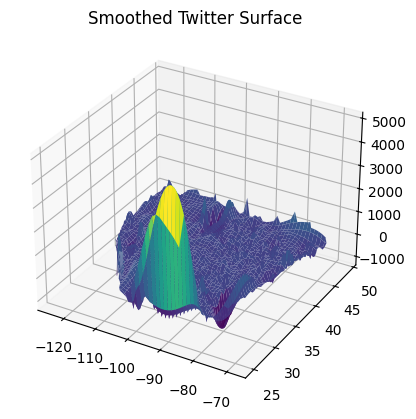

In [ ]:
Z_smooth = (grid_z[:-1,:-1] + grid_z[1:,:-1] + grid_z[:-1,1:] + grid_z[1:,1:]) / 4

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(grid_x[:-1,:-1], grid_y[:-1,:-1], Z_smooth, cmap='viridis')

ax.set_title("Smoothed Twitter Surface")
plt.show()

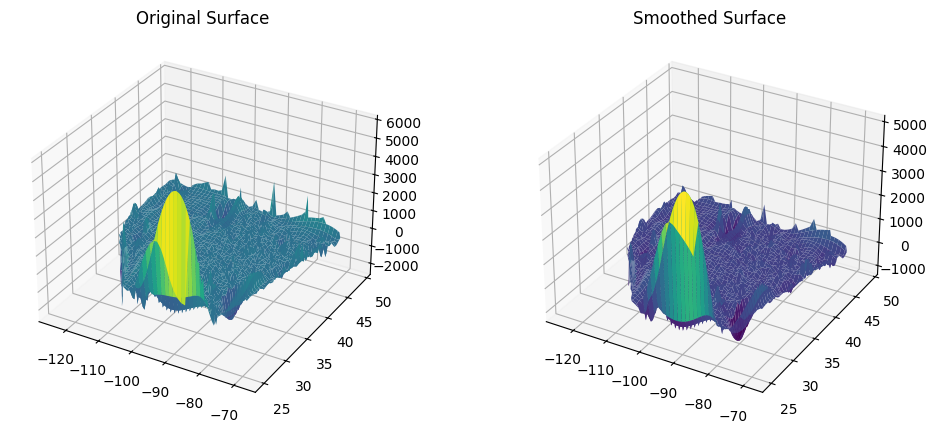

In [ ]:
fig = plt.figure(figsize=(12,5))

# Original
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')
ax1.set_title("Original Surface")

# Smoothed
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(grid_x[:-1,:-1], grid_y[:-1,:-1], Z_smooth, cmap='viridis')
ax2.set_title("Smoothed Surface")

plt.show()


## Reflection Questions

- Why do analytical surfaces fail for real-world data?
- What role does interpolation play?
- How does mesh resolution affect quality?
- Where are these techniques used in real life?


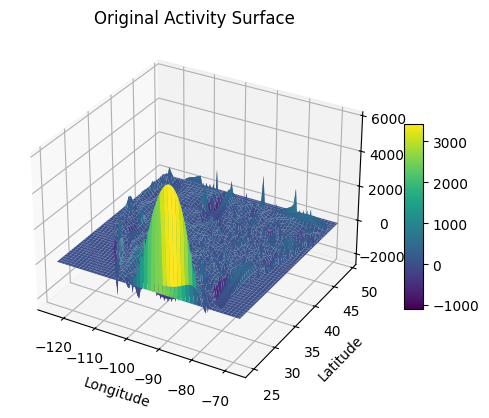

Model Mean Squared Error: 30348.217376785033


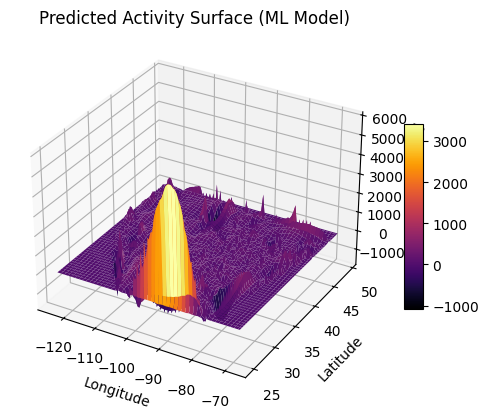

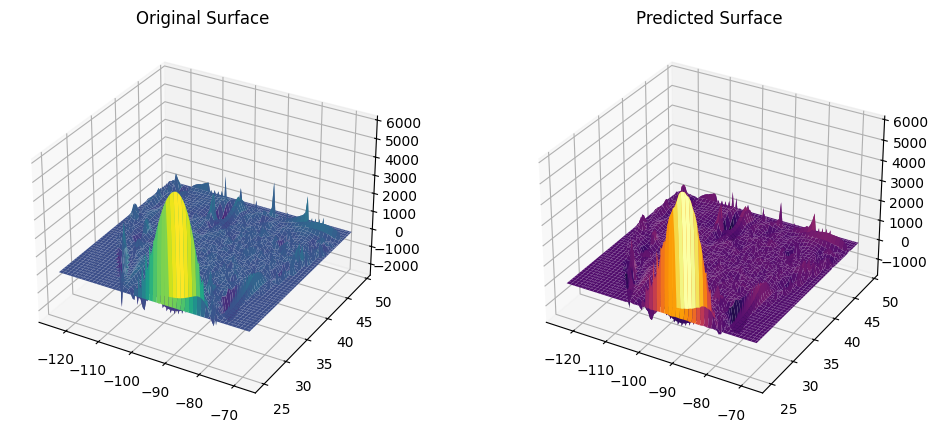

Predicted activity at new locations: [172.39497255   0.        ]


In [ ]:
# Surface Modeling + Machine Learning Pipeline
# Case Study: Urban Activity Prediction

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


url = "https://raw.githubusercontent.com/plotly/datasets/master/2014_us_cities.csv"
df = pd.read_csv(url)

# Extract coordinates
x = df['lon'].values
y = df['lat'].values

# Simulate activity (replace with real data if available)
np.random.seed(1)
z = np.random.rand(len(x)) * 200


grid_x, grid_y = np.mgrid[min(x):max(x):100j,
                          min(y):max(y):100j]

grid_z = griddata((x, y), z, (grid_x, grid_y), method='cubic')

# Handle NaN values (important)
grid_z = np.nan_to_num(grid_z)



fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, shrink=0.5, aspect=10)

ax.set_title("Original Activity Surface")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Activity")

plt.show()



# Flatten grid into features
features = np.column_stack((grid_x.ravel(), grid_y.ravel()))
targets = grid_z.ravel()



X_train, X_test, y_train, y_test = train_test_split(
    features, targets, test_size=0.2, random_state=42
)



model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)



y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Model Mean Squared Error:", mse)



predicted_z = model.predict(features).reshape(grid_x.shape)



fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(grid_x, grid_y, predicted_z, cmap='inferno', edgecolor='none')
fig.colorbar(surf, shrink=0.5, aspect=10)

ax.set_title("Predicted Activity Surface (ML Model)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Predicted Activity")

plt.show()



fig = plt.figure(figsize=(12,5))

# Original
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')
ax1.set_title("Original Surface")

# Predicted
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(grid_x, grid_y, predicted_z, cmap='inferno')
ax2.set_title("Predicted Surface")

plt.show()


new_locations = np.array([
    [x.mean(), y.mean()],
    [x.min(), y.max()]
])

predictions = model.predict(new_locations)

print("Predicted activity at new locations:", predictions)

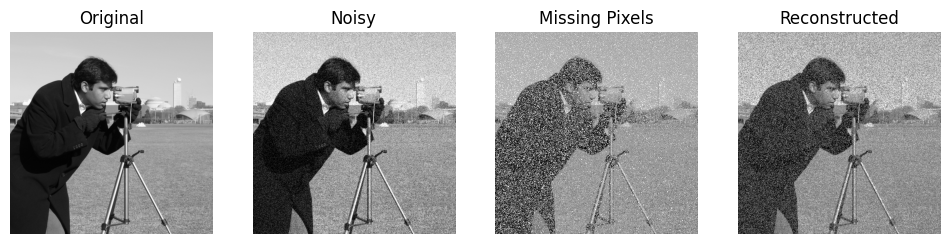

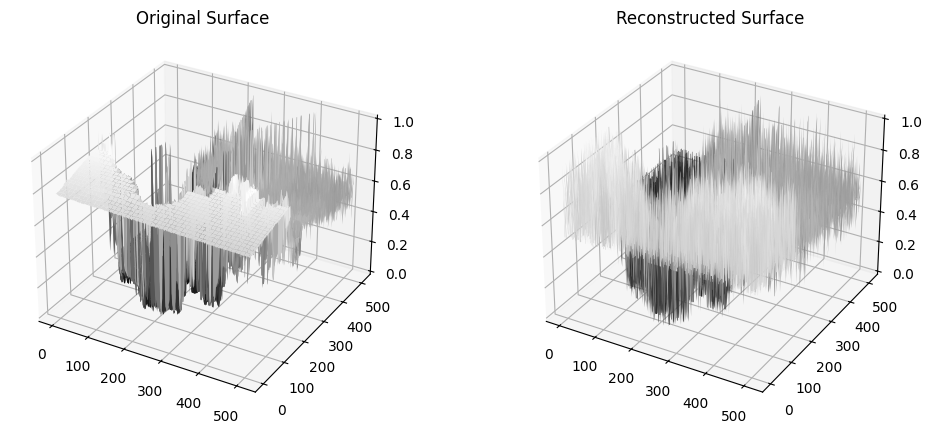

Reconstruction MSE: 0.03127334806395159


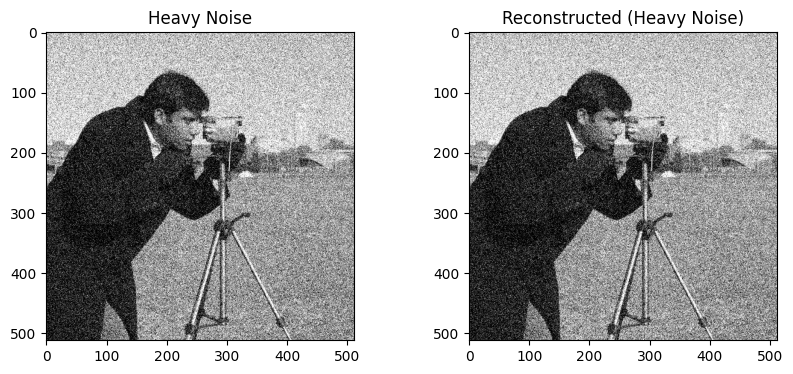

In [ ]:

# CASE STUDY: Image Enhancement using Surface Modeling


# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from skimage import data


# STEP 1: Load Image


image = data.camera()          # grayscale image
image = image / 255.0          # normalize to [0,1]

rows, cols = image.shape

# Create coordinate grid
x = np.arange(cols)
y = np.arange(rows)


# STEP 2: Add Noise (simulate real-world corruption)


np.random.seed(42)
noise = image + np.random.normal(0, 0.1, image.shape)
noise = np.clip(noise, 0, 1)


# STEP 3: Remove Some Pixels (Missing Data Scenario)


mask = np.random.rand(rows, cols) > 0.7   # remove 30% pixels
corrupted = noise.copy()
corrupted[mask] = np.nan


# STEP 4: Handle Missing Values (Initial Fill)


# Replace NaN with mean value (simple approach)
mean_val = np.nanmean(corrupted)
corrupted_filled = np.where(np.isnan(corrupted), mean_val, corrupted)


# STEP 5: Surface Modeling using B-Spline


# Create spline surface from corrupted image
spline = RectBivariateSpline(y, x, corrupted_filled)

# Reconstruct image (smooth surface)
reconstructed = spline(y, x)


# STEP 6: Visualization (2D comparison)


plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(noise, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(corrupted, cmap='gray')
plt.title("Missing Pixels")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

# STEP 7: 3D Surface Visualization


X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12,5))

# Original surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, image, cmap='gray', edgecolor='none')
ax1.set_title("Original Surface")

# Reconstructed surface
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, reconstructed, cmap='gray', edgecolor='none')
ax2.set_title("Reconstructed Surface")

plt.show()

# STEP 8: Error Analysis


mse = np.mean((image - reconstructed)**2)
print("Reconstruction MSE:", mse)

# STEP 9: Experiment (Stronger Noise)


noise_heavy = image + np.random.normal(0, 0.2, image.shape)
noise_heavy = np.clip(noise_heavy, 0, 1)

spline_heavy = RectBivariateSpline(y, x, noise_heavy)
reconstructed_heavy = spline_heavy(y, x)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(noise_heavy, cmap='gray')
plt.title("Heavy Noise")

plt.subplot(1,2,2)
plt.imshow(reconstructed_heavy, cmap='gray')
plt.title("Reconstructed (Heavy Noise)")

plt.show()

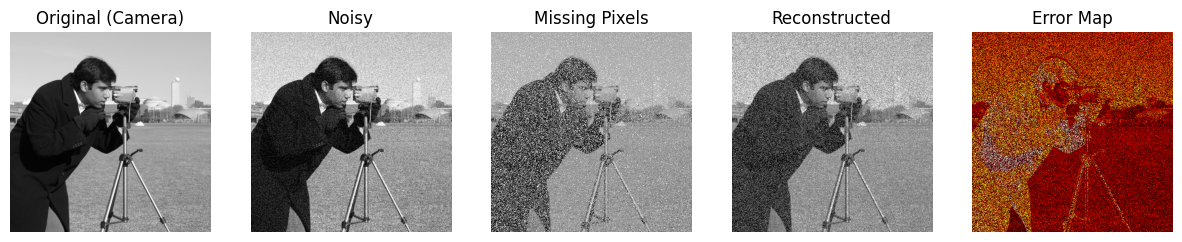

Camera - Reconstruction MSE: 0.03127334806395159


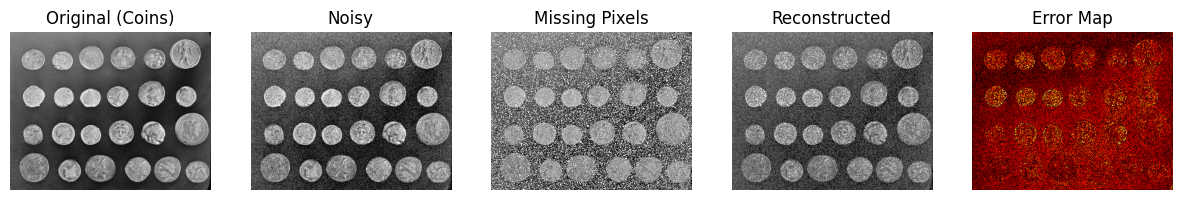

Coins - Reconstruction MSE: 0.019554205619862305


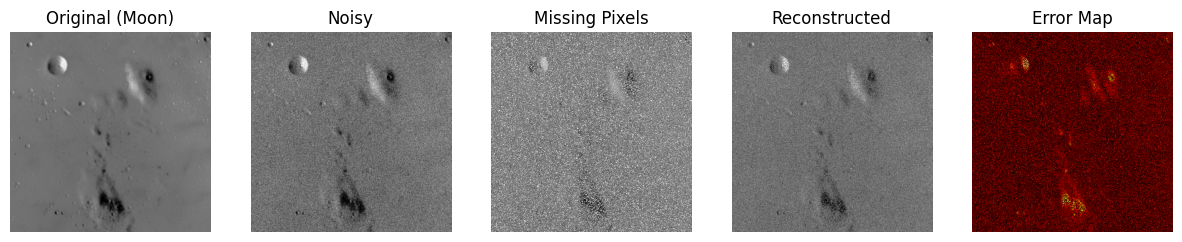

Moon - Reconstruction MSE: 0.007831540994131298


In [ ]:

# Image Enhancement using Surface Modeling
# (Improved Visualization: Before vs After)


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from skimage import data


# STEP 1: Load Multiple Sample Images


images = [
    data.camera() / 255.0,
    data.coins() / 255.0,
    data.moon() / 255.0
]

titles = ["Camera", "Coins", "Moon"]


# PROCESS EACH IMAGE


for idx, image in enumerate(images):

    rows, cols = image.shape
    x = np.arange(cols)
    y = np.arange(rows)


    # STEP 2: Add Noise

    np.random.seed(42)
    noise = image + np.random.normal(0, 0.1, image.shape)
    noise = np.clip(noise, 0, 1)


    # STEP 3: Remove Pixels (Missing Data)

    mask = np.random.rand(rows, cols) > 0.7
    corrupted = noise.copy()
    corrupted[mask] = np.nan


    # STEP 4: Fill Missing Values

    mean_val = np.nanmean(corrupted)
    corrupted_filled = np.where(np.isnan(corrupted), mean_val, corrupted)


    # STEP 5: B-Spline Reconstruction

    spline = RectBivariateSpline(y, x, corrupted_filled)
    reconstructed = spline(y, x)


    # STEP 6: Error Map

    error = np.abs(image - reconstructed)


    # STEP 7: DISPLAY RESULTS


    plt.figure(figsize=(15,4))

    plt.subplot(1,5,1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original ({titles[idx]})")
    plt.axis('off')

    plt.subplot(1,5,2)
    plt.imshow(noise, cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(1,5,3)
    plt.imshow(corrupted, cmap='gray')
    plt.title("Missing Pixels")
    plt.axis('off')

    plt.subplot(1,5,4)
    plt.imshow(reconstructed, cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

    plt.subplot(1,5,5)
    plt.imshow(error, cmap='hot')
    plt.title("Error Map")
    plt.axis('off')

    plt.show()


    # STEP 8: PRINT ERROR METRIC

    mse = np.mean((image - reconstructed)**2)
    print(f"{titles[idx]} - Reconstruction MSE:", mse)

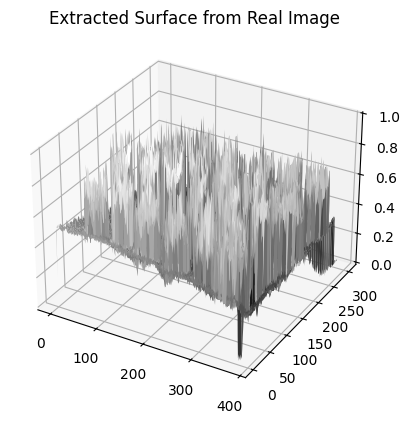

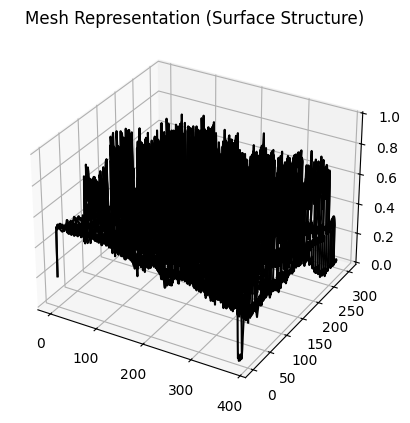

Accuracy: 0.7853950610210279


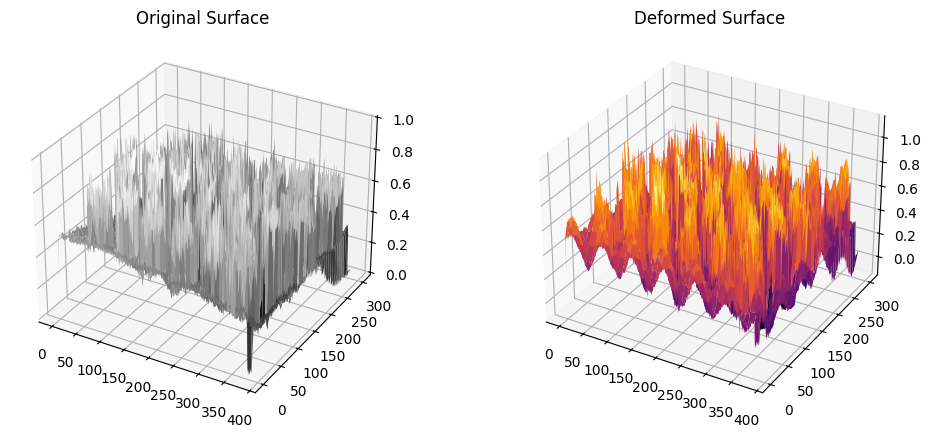

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import data
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# STEP 1: Load REAL dataset (image = height map)
image = data.coins() / 255.0   # real dataset
rows, cols = image.shape

# STEP 2: Extract Surface (Height Map)
x = np.arange(cols)
y = np.arange(rows)

X, Y = np.meshgrid(x, y)
Z = image   # height = pixel intensity

# STEP 3: Visualize Extracted Surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='gray', edgecolor='none')
ax.set_title("Extracted Surface from Real Image")

plt.show()

# STEP 4: Mesh Representation
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(X, Y, Z, color='black')
ax.set_title("Mesh Representation (Surface Structure)")

plt.show()

# STEP 5: Surface Modification (Deformation)
Z_deformed = Z + 0.2 * np.sin(X / 10) * np.cos(Y / 10)


# STEP 6: Feature Extraction for ML
features_original = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
features_deformed = np.column_stack((X.ravel(), Y.ravel(), Z_deformed.ravel()))

X_data = np.vstack((features_original, features_deformed))

# Labels
y_data = np.array([0]*len(features_original) + [1]*len(features_deformed))

# STEP 7: Train ML Model
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# STEP 8: Evaluate Model
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

# STEP 9: Visual Comparison
fig = plt.figure(figsize=(12,5))

# Original surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='gray')
ax1.set_title("Original Surface")

# Deformed surface
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z_deformed, cmap='inferno')
ax2.set_title("Deformed Surface")

plt.show()